<a href="https://colab.research.google.com/github/mejian1/ExopherGeneExpressionProfiling/blob/main/memeFIMOpermanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
!pip install -q condacolab==0.1.7
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


Note: `condacolab.install()` will restart the kernel automatically. After the kernel restarts, run the next cell to install the MEME suite.

In [11]:
!mamba install -y -c conda-forge -c bioconda meme biopython

[+] 0.0s
[+] 0.0s
[+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch    ⣾  
bioconda/linux-64     ⣾  
bioconda/noarch       ⣾  [+] 0.2s
conda-forge/linux-64   7%
conda-forge/noarch     8%
bioconda/linux-64     39%
bioconda/noarch       18%[+] 0.3s
conda-forge/linux-64  12%
conda-forge/noarch    18%
bioconda/linux-64     88%
bioconda/noarch       68%bioconda/linux-64                                 
[+] 0.4s
conda-forge/linux-64  13%
conda-forge/noarch    20%
bioconda/noarch       83%bioconda/noarch                                   
[+] 0.5s
conda-forge/linux-64  20%
conda-forge/noarch    34%[+] 0.6s
conda-forge/linux-64  29%
conda-forge/noarch    52%[+] 0.7s
conda-forge/linux-64  39%
conda-forge/noarch    72%[+] 0.8s
conda-forge/linux-64  48%
conda-forge/noarch    92%[+] 0.9s
conda-forge/linux-64  48%
conda-forge/noarch    92%conda-forge/noarch                                
[+] 1.0s
conda-forge/linux-64  60%[+] 1.1s
conda-forge/linux-64  68%[+] 1.2s
conda-forge/linux-64  76%[+] 1

In [12]:
# Run FIMO using the MEME suite directly via the command line
!fimo --oc fimo_out /content/jaspar2024_core_nematodes.meme /content/all_perm_promoters_combined.fa

Using motif +MA0260.1 of width 6.
Using motif -MA0260.1 of width 6.
Finding best site passing the output threshold in each of the 22 sequences.
Found a best site in 0 sequences.
Computing q-values.
Using motif +MA0261.1 of width 6.
Using motif -MA0261.1 of width 6.
Finding best site passing the output threshold in each of the 22 sequences.
Found a best site in 0 sequences.
Computing q-values.
Using motif +MA0262.1 of width 13.
Using motif -MA0262.1 of width 13.
Finding best site passing the output threshold in each of the 22 sequences.
Found a best site in 18 sequences.
Computing q-values.
# Computing q-values.
#   Estimating pi_0 from a uniformly sampled set of 10000 p-values.
#   Estimating pi_0.
# Minimal pi_zero = 0.9242
#   Estimated pi_0=0.938954
Using motif +MA0263.1 of width 14.
Using motif -MA0263.1 of width 14.
Finding best site passing the output threshold in each of the 22 sequences.
Found a best site in 7 sequences.
Computing q-values.
# Computing q-values.
#   Estimating 

In [13]:
# Alternatively, if you want to use your provided python script:
!python /content/run_fimo.py

22 sequences indexed from all_perm_promoters_combined.fa

SKIP C._elegans_(reference): genome not found at genomes/caenorhabditis_elegans.fa.gz (run download_genomes.py first)
SKIP caenorhabditis_quiockensis: genome not found at genomes/caenorhabditis_quiockensis.fa.gz (run download_genomes.py first)
SKIP caenorhabditis_nigoni: genome not found at genomes/caenorhabditis_nigoni.fa.gz (run download_genomes.py first)
SKIP caenorhabditis_auriculariae: genome not found at genomes/caenorhabditis_auriculariae.fa.gz (run download_genomes.py first)
SKIP caenorhabditis_sulstoni: genome not found at genomes/caenorhabditis_sulstoni.fa.gz (run download_genomes.py first)
SKIP caenorhabditis_panamensis: genome not found at genomes/caenorhabditis_panamensis.fa.gz (run download_genomes.py first)
SKIP caenorhabditis_inopinata: genome not found at genomes/caenorhabditis_inopinata.fa.gz (run download_genomes.py first)
SKIP caenorhabditis_briggsae: genome not found at genomes/caenorhabditis_briggsae.fa.gz 

### Best Visualizations for Motif Analysis (FIMO)

When analyzing Transcription Factor (TF) binding motifs across a gene family (like the *perm* genes) and multiple species, the following visualizations are standard and highly informative:

1. **Motif Occurrence / Frequency Bar Charts**:
   - **What it shows:** Which motifs appear most frequently across your sequences.
   - **Why it's useful:** Quickly identifies the dominant TFs that might be regulating your gene family.

2. **Positional Distribution (Density Plots or Histograms)**:
   - **What it shows:** Where the motifs are located within the promoter sequence (e.g., concentrated near the transcription start site [TSS] or spread out?).
   - **Why it's useful:** True biological regulatory elements often cluster at specific distances relative to the TSS.

3. **Phylogenetic / Species Heatmaps**:
   - **What it shows:** A matrix where rows are species (ideally ordered by an evolutionary tree) and columns are motifs. Colors represent the count of motifs or the best p-value.
   - **Why it's useful:** Allows you to see motif conservation or loss across evolution. (*Note: You can build this once your `aggregate_results.py` finishes successfully on all species*).

4. **Motif Maps (Sequence Tracks / Lollipops)**:
   - **What it shows:** A literal map of the sequence (a straight line) with colored blocks or lollipops showing exactly where each motif binds.
   - **Why it's useful:** Great for checking if motifs co-occur in clusters or specific arrangements.

Let's generate the first two (Frequency and Positional Distribution) using the results from your direct FIMO run on `all_perm_promoters_combined.fa`!

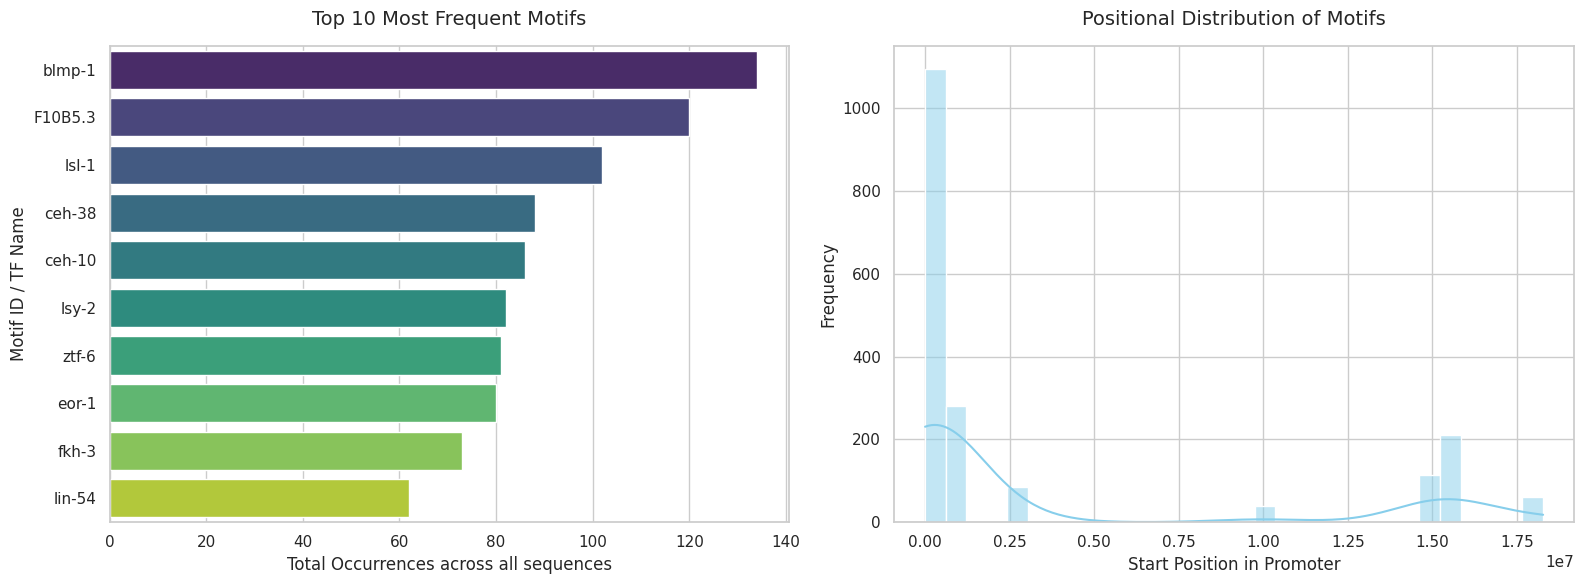

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Load the FIMO TSV results
# FIMO outputs often have a few footer rows with comments starting with '#', so we drop rows missing motif_id
fimo_tsv_path = '/content/fimo_out/fimo.tsv'

try:
    fimo_df = pd.read_csv(fimo_tsv_path, sep='\t')
    fimo_df = fimo_df.dropna(subset=['motif_id'])

    # The last few rows in a FIMO TSV can sometimes be empty or just text,
    # let's ensure we are working with the data rows.
    fimo_df = fimo_df[fimo_df['motif_id'].str.len() > 0]

    # Convert positions to numeric
    fimo_df['start'] = pd.to_numeric(fimo_df['start'], errors='coerce')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- Plot 1: Top 10 Most Frequent Motifs ---
    # If 'motif_alt_id' (usually the TF name) is available and not fully empty, use it, else use 'motif_id'
    motif_col = 'motif_alt_id' if 'motif_alt_id' in fimo_df.columns and not fimo_df['motif_alt_id'].isnull().all() else 'motif_id'

    top_motifs = fimo_df[motif_col].value_counts().head(10)

    sns.barplot(y=top_motifs.index, x=top_motifs.values, hue=top_motifs.index, ax=axes[0], palette="viridis", legend=False)
    axes[0].set_title('Top 10 Most Frequent Motifs', fontsize=14, pad=15)
    axes[0].set_xlabel('Total Occurrences across all sequences')
    axes[0].set_ylabel('Motif ID / TF Name')

    # --- Plot 2: Distribution of Motif Start Positions ---
    sns.histplot(data=fimo_df, x='start', bins=30, kde=True, color='skyblue', ax=axes[1])
    axes[1].set_title('Positional Distribution of Motifs', fontsize=14, pad=15)
    axes[1].set_xlabel('Start Position in Promoter')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"File {fimo_tsv_path} not found. Please ensure the FIMO analysis completed successfully.")
except Exception as e:
    print(f"An error occurred while plotting: {e}")

*(Note: I noticed your automated multi-species script `run_fimo.py` skipped many species because it couldn't find the genomes in the `genomes/` directory. You will need to run your `download_genomes.py` script first to fetch those FASTA files before `run_fimo.py` can generate the multi-species summary table!)*

In [16]:
!python /content/download_genomes.py

downloading: caenorhabditis_elegans
curl: /usr/local/lib/libcurl.so.4: no version information available (required by curl)
  size: 29,131,150 bytes
downloading: caenorhabditis_quiockensis
curl: /usr/local/lib/libcurl.so.4: no version information available (required by curl)
  size: 28,899,963 bytes
downloading: caenorhabditis_nigoni
curl: /usr/local/lib/libcurl.so.4: no version information available (required by curl)
  size: 36,600,195 bytes
downloading: caenorhabditis_auriculariae
curl: /usr/local/lib/libcurl.so.4: no version information available (required by curl)
  size: 33,453,884 bytes
downloading: caenorhabditis_sulstoni
curl: /usr/local/lib/libcurl.so.4: no version information available (required by curl)
  size: 19,162,696 bytes
downloading: caenorhabditis_panamensis
curl: /usr/local/lib/libcurl.so.4: no version information available (required by curl)
  size: 23,184,210 bytes
downloading: caenorhabditis_inopinata
curl: /usr/local/lib/libcurl.so.4: no version information avai

Once the genomes are downloaded, run the next two cells to perform the multi-species FIMO analysis and build the summary table.

In [17]:
!python /content/run_fimo.py

22 sequences indexed from all_perm_promoters_combined.fa

done: C._elegans_(reference)
done: caenorhabditis_quiockensis
done: caenorhabditis_nigoni
done: caenorhabditis_auriculariae
done: caenorhabditis_sulstoni
done: caenorhabditis_panamensis
done: caenorhabditis_inopinata
done: caenorhabditis_briggsae
done: caenorhabditis_bovis
done: caenorhabditis_brenneri
done: caenorhabditis_sinica
done: caenorhabditis_latens
done: caenorhabditis_tropicalis
done: caenorhabditis_tribulationis
done: caenorhabditis_uteleia
done: caenorhabditis_zanzibari
done: caenorhabditis_becei
done: caenorhabditis_japonica
done: caenorhabditis_parvicauda_innermost
done: Oscheius_tipulae_PRJEB15512
done: Haemonchus_contortus_PRJEB506
done: Necator_americanus_PRJNA1007425

All FIMO runs complete. Results in fimo_results/<species>_out/fimo.tsv
Run aggregate_results.py next to build the summary table.


In [19]:
!python /content/aggregate_results.py

# Let's peek at the generated summary table
import pandas as pd
try:
    df_summary = pd.read_csv('/content/fimo_summary.csv')
    display(df_summary.head())
except FileNotFoundError:
    print("Summary matrix not found. Please ensure the aggregation script completed successfully.")

species                             end-3    elt-6    elt-3   unc-86   ceh-18    xbp-1   ceh-23   blmp-1    fkh-9
C._elegans_(reference)                 --       --       --    0.119    0.238    0.196       --    0.143    0.107
caenorhabditis_quiockensis             --       --       --       --    0.059       --       --    0.005       --
caenorhabditis_nigoni                  --       --    0.033       --       --       --       --    0.029       --
caenorhabditis_auriculariae            --       --       --       --       --       --       --    0.015    0.056
caenorhabditis_sulstoni                --       --       --       --       --       --       --    0.005    0.048
caenorhabditis_panamensis              --       --    0.065       --       --       --       --    0.041    0.090
caenorhabditis_inopinata               --       --    0.089       --       --       --       --       --    0.048
caenorhabditis_briggsae                --       --    0.061       --       --       --  

,species,end-3,elt-6,elt-3,unc-86,ceh-18,xbp-1,ceh-23,blmp-1,fkh-9
0,C._elegans_(reference),NaN,NaN,NaN,0.119,0.2380,0.196,NaN,0.14300,0.1070
1,caenorhabditis_quiockensis,NaN,NaN,NaN,NaN,0.0594,NaN,NaN,0.00466,NaN
2,caenorhabditis_nigoni,NaN,NaN,0.0329,NaN,NaN,NaN,NaN,0.02860,NaN
3,caenorhabditis_auriculariae,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01480,0.0556
4,caenorhabditis_sulstoni,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00539,0.0475


### 3. Phylogenetic / Species Heatmap

Now we can visualize the conservation of motifs across the different species based on the best p-value or q-value (here represented by significance scores in our summary table).

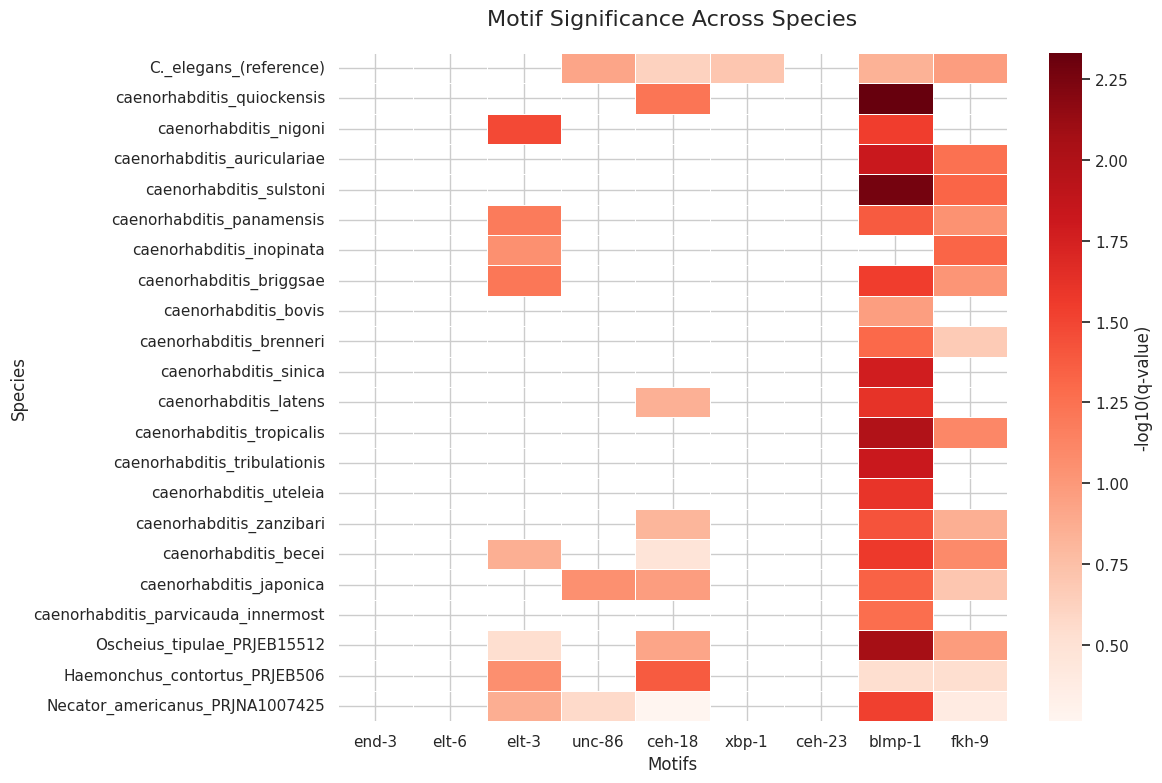

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the summary matrix
# We will replace '--' with a high non-significant value (like 1.0) for plotting purposes
try:
    df_summary = pd.read_csv('/content/fimo_summary.csv')

    # Set the species column as index
    df_summary.set_index('species', inplace=True)

    # Replace '--' with 1.0 (indicating non-significant / missing motif)
    df_summary.replace('--', 1.0, inplace=True)

    # Convert all columns to numeric floats
    df_summary = df_summary.apply(pd.to_numeric, errors='coerce')

    # For visualization, it's often better to plot -log10(p-value or q-value)
    # so that higher values mean higher significance.
    # We'll cap values to avoid log(0) issues.
    min_val = df_summary[df_summary > 0].min().min() # find minimum non-zero value
    df_summary_log = -np.log10(df_summary.replace(0, min_val))

    # Plotting
    plt.figure(figsize=(12, 8))
    # Using a colormap where higher significance is darker/more intense
    sns.heatmap(df_summary_log, cmap='Reds', linewidths=.5,
                cbar_kws={'label': '-log10(q-value)'})

    plt.title('Motif Significance Across Species', fontsize=16, pad=20)
    plt.xlabel('Motifs', fontsize=12)
    plt.ylabel('Species', fontsize=12)
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Could not find /content/fimo_summary.csv")
except Exception as e:
    print(f"An error occurred: {e}")

### Exporting Results to Google Drive

The following cell will create a directory in your Google Drive and save the tables (`.csv`/`.tsv`) along with high-resolution `.png` files of the plots we just created.

In [21]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

# Define Google Drive output directory
drive_dir = '/content/drive/MyDrive/Perm_Motif_Analysis'
os.makedirs(drive_dir, exist_ok=True)
print(f"Saving results to {drive_dir}...")

# 1. Copy Tabular Data
shutil.copy('/content/fimo_summary.csv', os.path.join(drive_dir, 'fimo_summary.csv'))
shutil.copy('/content/fimo_out/fimo.tsv', os.path.join(drive_dir, 'all_perm_promoters_fimo.tsv'))
print("- Saved tabular data.")

# 2. Re-create and Save Plot 1 & 2 (Frequency & Position)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# We use the variables `top_motifs` and `fimo_df` still in memory
sns.barplot(y=top_motifs.index, x=top_motifs.values, hue=top_motifs.index, ax=axes[0], palette="viridis", legend=False)
axes[0].set_title('Top 10 Most Frequent Motifs', fontsize=14, pad=15)
axes[0].set_xlabel('Total Occurrences across all sequences')
axes[0].set_ylabel('Motif ID / TF Name')

sns.histplot(data=fimo_df, x='start', bins=30, kde=True, color='skyblue', ax=axes[1])
axes[1].set_title('Positional Distribution of Motifs', fontsize=14, pad=15)
axes[1].set_xlabel('Start Position in Promoter')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(drive_dir, 'motif_frequency_and_position.png'), dpi=300, bbox_inches='tight')
plt.close() # Close to prevent displaying it again
print("- Saved Motif Frequency and Positional Distribution plot.")

# 3. Re-create and Save Plot 3 (Phylogenetic Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(df_summary_log, cmap='Reds', linewidths=.5, cbar_kws={'label': '-log10(q-value)'})
plt.title('Motif Significance Across Species', fontsize=16, pad=20)
plt.xlabel('Motifs', fontsize=12)
plt.ylabel('Species', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(drive_dir, 'phylogenetic_motif_heatmap.png'), dpi=300, bbox_inches='tight')
plt.close()
print("- Saved Phylogenetic Motif Heatmap.")

print("\nAll files successfully exported to your Google Drive!")

Saving results to /content/drive/MyDrive/Perm_Motif_Analysis...
- Saved tabular data.
- Saved Motif Frequency and Positional Distribution plot.
- Saved Phylogenetic Motif Heatmap.

All files successfully exported to your Google Drive!


### Downstream Analysis 1: Motif Co-occurrence

Are certain transcription factors binding together? Let's build a correlation matrix based on the counts of motifs in each promoter sequence.

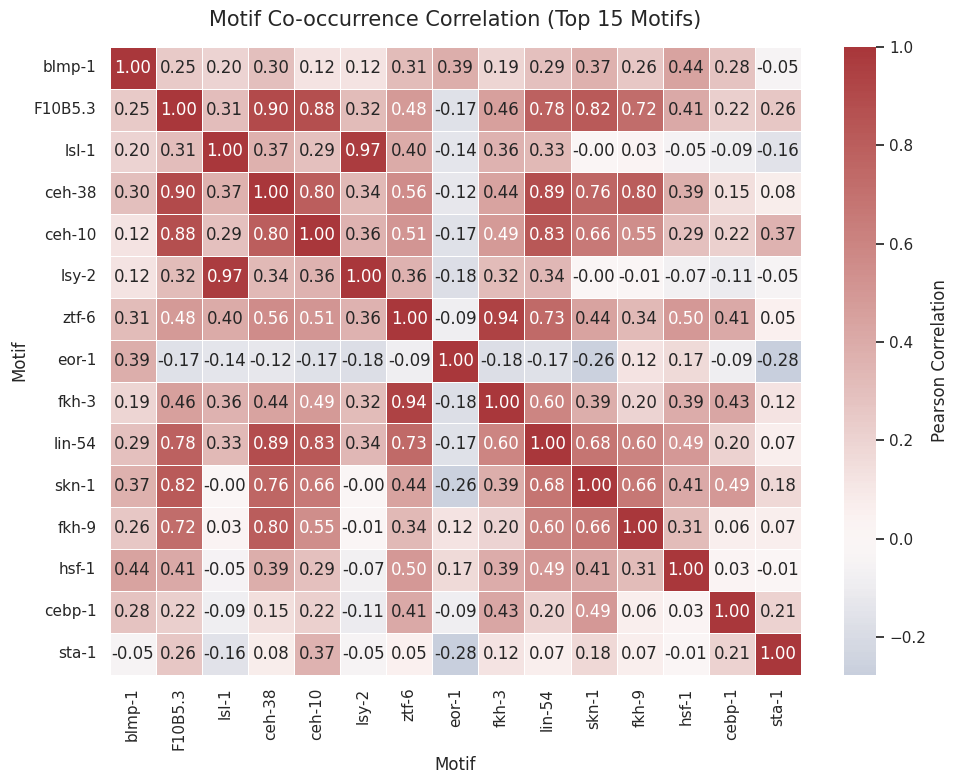

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# We will use the fimo_df loaded previously
motif_col = 'motif_alt_id' if 'motif_alt_id' in fimo_df.columns and not fimo_df['motif_alt_id'].isnull().all() else 'motif_id'

# Create a matrix of sequence vs motif counts
# pd.crosstab computes the frequency of each motif per sequence
co_mat = pd.crosstab(fimo_df['sequence_name'], fimo_df[motif_col])

# Keep the top 15 most frequent motifs to keep the visualization clean
top_n = 15
top_motifs_list = co_mat.sum().sort_values(ascending=False).head(top_n).index
co_mat_top = co_mat[top_motifs_list]

# Calculate the Pearson correlation matrix between motifs
corr_matrix = co_mat_top.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0, fmt=".2f",
            linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})

plt.title(f'Motif Co-occurrence Correlation (Top {top_n} Motifs)', fontsize=15, pad=15)
plt.xlabel('Motif')
plt.ylabel('Motif')
plt.tight_layout()
plt.show()

### Downstream Analysis 2: Custom Sequence Logos

Let's extract the actual matched sequences from your promoters for the most frequent motif (e.g., `blmp-1`) and build a custom sequence logo to see its binding preferences in the *perm* gene family.

In [23]:
!pip install -q logomaker

Building sequence logo for the top motif: blmp-1


<Figure size 1000x300 with 0 Axes>

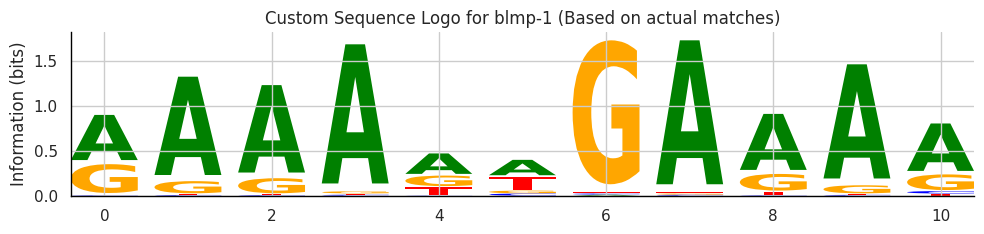

In [24]:
import logomaker
import matplotlib.pyplot as plt

# Get the top motif name
top_motif_name = top_motifs.index[0]
print(f"Building sequence logo for the top motif: {top_motif_name}")

# Filter FIMO dataframe for this motif and extract the matched sequences
motif_seqs = fimo_df[fimo_df[motif_col] == top_motif_name]['matched_sequence'].dropna().astype(str).str.upper().tolist()

if len(motif_seqs) > 0:
    # Create a count matrix
    counts_mat = logomaker.alignment_to_matrix(sequences=motif_seqs, to_type='counts', characters_to_ignore='.-N')

    # Convert to information weight matrix (bits)
    info_mat = logomaker.transform_matrix(counts_mat, from_type='counts', to_type='information')

    # Plot the logo
    plt.figure(figsize=(10, 3))
    logo = logomaker.Logo(info_mat, color_scheme='classic', vpad=.1, width=.8)
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)
    plt.title(f'Custom Sequence Logo for {top_motif_name} (Based on actual matches)')
    plt.ylabel('Information (bits)')
    plt.tight_layout()
    plt.show()
else:
    print(f"No valid sequence matches found to build a logo for {top_motif_name}.")

### Downstream Analysis 3: Evolutionary Trait Mapping (Clustermap)

We will perform hierarchical clustering on the motif significance matrix to create a pseudo-phylogenetic tree based purely on regulatory motif conservation.

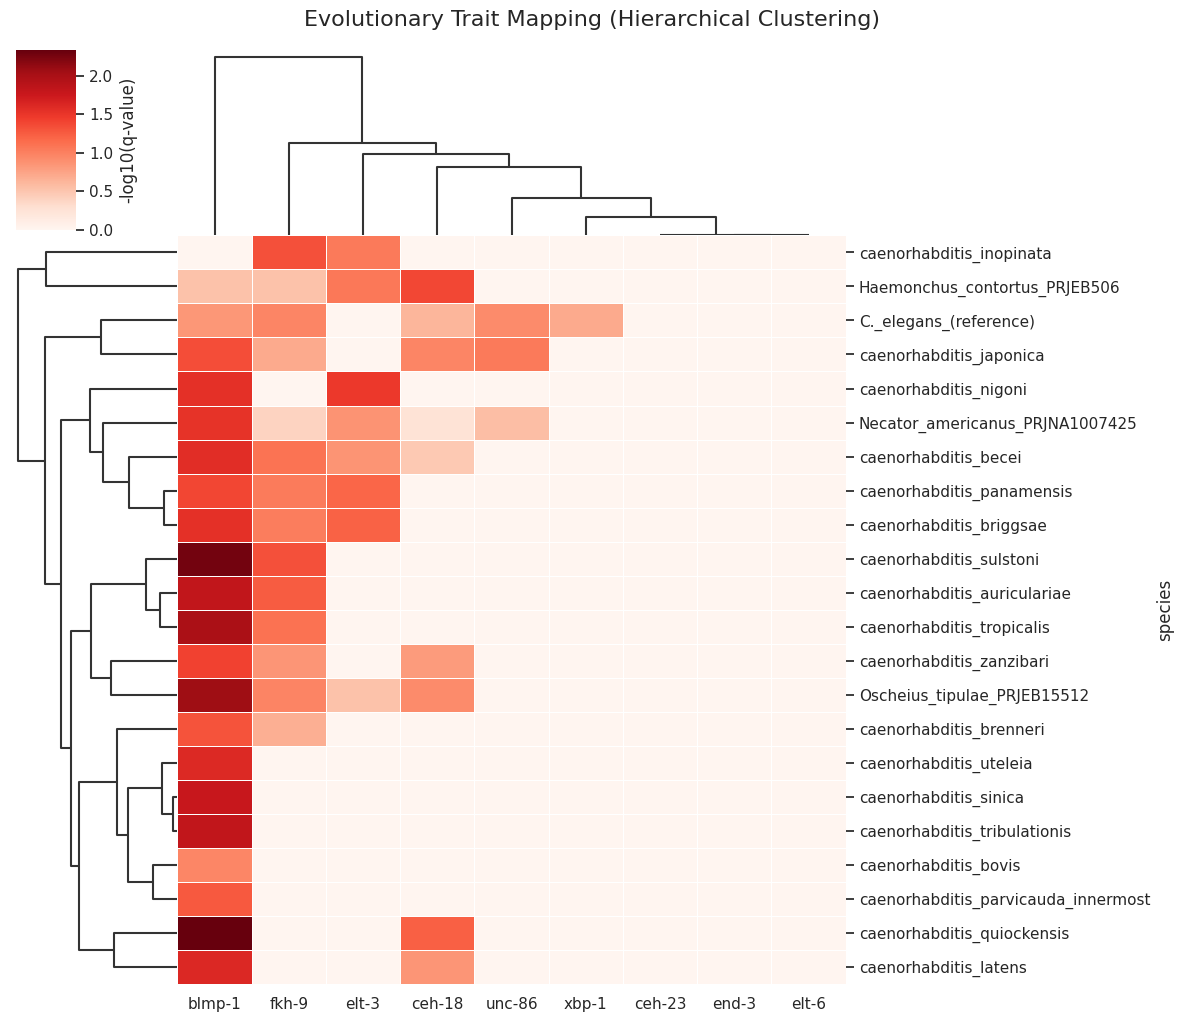

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# We use df_summary_log which we prepared earlier
# Fill NaNs with 0 for clustering (0 means not significant/absent)
df_clust = df_summary_log.fillna(0)

# Create a clustermap
g = sns.clustermap(df_clust, cmap='Reds', figsize=(12, 10),
                   method='average', metric='euclidean',
                   cbar_kws={'label': '-log10(q-value)'},
                   linewidths=0.5, tree_kws={'linewidths': 1.5})

plt.suptitle('Evolutionary Trait Mapping (Hierarchical Clustering)', y=1.02, fontsize=16)
plt.show()

### Downstream Analysis 4: Distance-to-TSS Analysis

Finally, let's analyze exactly where the top 5 motifs are binding. A violin plot will show us the density of binding sites at different positions in the promoter sequence.

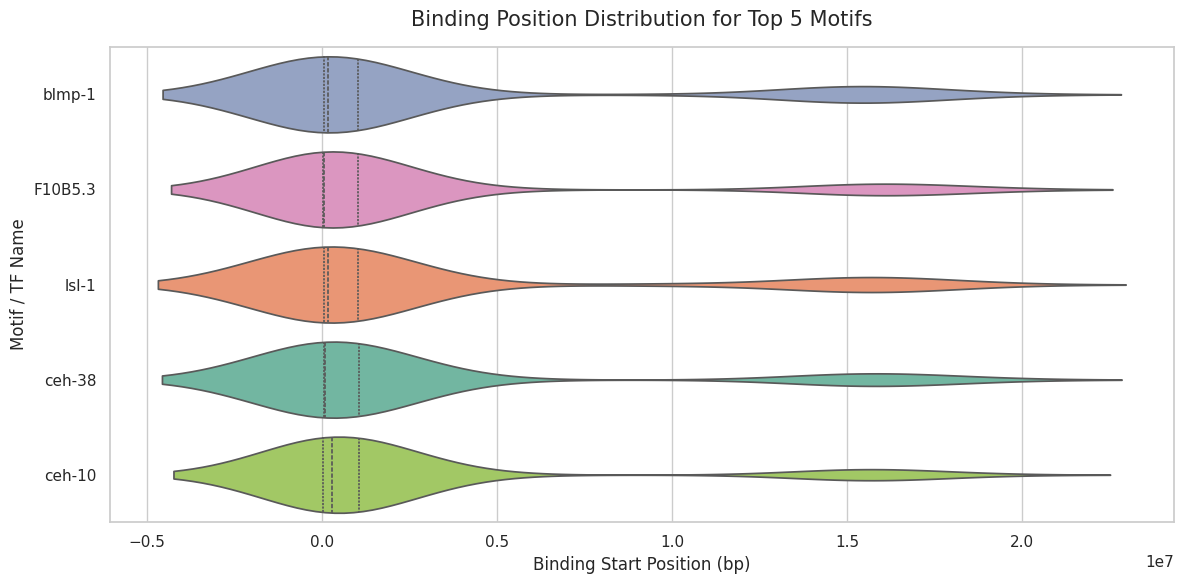

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the top 5 motifs
top_5_motifs = top_motifs.head(5).index

# Filter the FIMO data for only these 5 motifs
subset_fimo = fimo_df[fimo_df[motif_col].isin(top_5_motifs)]

plt.figure(figsize=(12, 6))
# Create a violin plot to show density distributions
sns.violinplot(data=subset_fimo, x='start', y=motif_col, hue=motif_col, order=top_5_motifs,
               palette="Set2", inner="quartile", legend=False)

plt.title('Binding Position Distribution for Top 5 Motifs', fontsize=15, pad=15)
plt.xlabel('Binding Start Position (bp)')
plt.ylabel('Motif / TF Name')
plt.tight_layout()
plt.show()

### Export Downstream Visualizations to Google Drive

Run this cell to save the high-resolution versions of the 4 downstream plots to your connected Google Drive.

In [28]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import logomaker

drive_dir = '/content/drive/MyDrive/Perm_Motif_Analysis'
os.makedirs(drive_dir, exist_ok=True)
print(f"Saving downstream plots to {drive_dir}...")

# 1. Save Co-occurrence Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0, fmt=".2f",
            linewidths=0.5, cbar_kws={'label': 'Pearson Correlation'})
plt.title(f'Motif Co-occurrence Correlation (Top {top_n} Motifs)', fontsize=15, pad=15)
plt.xlabel('Motif')
plt.ylabel('Motif')
plt.tight_layout()
plt.savefig(os.path.join(drive_dir, 'motif_co_occurrence.png'), dpi=300, bbox_inches='tight')
plt.close()
print("- Saved Co-occurrence Heatmap.")

# 2. Save Sequence Logo
if len(motif_seqs) > 0:
    plt.figure(figsize=(10, 3))
    logo = logomaker.Logo(info_mat, color_scheme='classic', vpad=.1, width=.8)
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)
    plt.title(f'Custom Sequence Logo for {top_motif_name}')
    plt.ylabel('Information (bits)')
    plt.tight_layout()
    plt.savefig(os.path.join(drive_dir, f'sequence_logo_{top_motif_name}.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"- Saved Sequence Logo for {top_motif_name}.")

# 3. Save Clustermap
g = sns.clustermap(df_clust, cmap='Reds', figsize=(12, 10),
                   method='average', metric='euclidean',
                   cbar_kws={'label': '-log10(q-value)'},
                   linewidths=0.5, tree_kws={'linewidths': 1.5})
plt.suptitle('Evolutionary Trait Mapping (Hierarchical Clustering)', y=1.02, fontsize=16)
g.savefig(os.path.join(drive_dir, 'evolutionary_trait_clustermap.png'), dpi=300, bbox_inches='tight')
plt.close()
print("- Saved Evolutionary Trait Clustermap.")

# 4. Save Distance-to-TSS Violin Plot
plt.figure(figsize=(12, 6))
sns.violinplot(data=subset_fimo, x='start', y=motif_col, hue=motif_col, order=top_5_motifs,
               palette="Set2", inner="quartile", legend=False)
plt.title('Binding Position Distribution for Top 5 Motifs', fontsize=15, pad=15)
plt.xlabel('Binding Start Position (bp)')
plt.ylabel('Motif / TF Name')
plt.tight_layout()
plt.savefig(os.path.join(drive_dir, 'distance_to_tss_violin.png'), dpi=300, bbox_inches='tight')
plt.close()
print("- Saved Distance-to-TSS Violin Plot.")

print("\nAll downstream visualizations successfully exported to Google Drive!")

Saving downstream plots to /content/drive/MyDrive/Perm_Motif_Analysis...
- Saved Co-occurrence Heatmap.
- Saved Sequence Logo for blmp-1.
- Saved Evolutionary Trait Clustermap.
- Saved Distance-to-TSS Violin Plot.

All downstream visualizations successfully exported to Google Drive!


<Figure size 1000x300 with 0 Axes>

In the Evolutionary Trait Mapping Clustermap you just generated, the clustering happens on two axes (rows and columns), and each tells a distinct biological story about the perm gene family:

1. Species Clusters (Rows - The Vertical Tree)
Instead of grouping species by their standard genomic DNA similarity, this tree groups them by regulatory architecture.

Conserved Regulation: Species that cluster tightly together have a very similar presence/absence of TF binding sites in their perm promoters.
Evolutionary Divergence: If you notice that parasitic species (like Haemonchus contortus or Necator americanus) cluster separately from free-living Caenorhabditis species, it suggests that the regulatory network controlling the perm genes adapted specifically for parasitism.
Phylogenetic Concordance: If this tree perfectly matches the known nematode evolutionary tree, it implies these regulatory motifs have been steadily conserved over time. If it differs, it suggests rapid regulatory rewiring or convergent evolution in specific lineages.
2. Motif Clusters (Columns - The Horizontal Tree)
This groups transcription factors (motifs) based on how often they are co-conserved across the species.

Core Regulatory Hubs: Looking at the summary table, blmp-1 is highly significant across almost all species (17 out of 22). It likely forms its own distinct cluster or acts as an anchor, indicating it is a fundamental, ancient regulator of the perm gene family.
Co-functioning TFs: Motifs that cluster tightly together (e.g., perhaps fkh-9 and elt-3 if they share similar presence profiles) are retained or lost together during evolution. This is a strong indicator that these TFs might physically interact, form a complex, or be required together to activate the gene in specific tissues.
In Summary
Darker red blocks represent high confidence (high significance) of a motif in a species. A solid vertical dark red band means an ancient, highly conserved TF (like blmp-1). Patchy, clustered blocks indicate lineage-specific regulatory networks that evolved in specific subsets of these nematodes.